# Section 05 — Hybrid Recommender Systems

Every approach we've built has blind spots:

| Model | Fails on |
|---|---|
| Collaborative Filtering | New users, new items (cold start) |
| Content-Based | Users with no taste history |
| Matrix Factorization | Both cold starts; opaque |
| Neural CF | Same as MF, needs more data |

Hybrid systems **combine multiple models** to cover each other's blind spots.

This section builds four hybrid strategies:

1. **Weighted hybrid** — linearly blend scores from multiple models. Simple, often effective.
2. **Switching hybrid** — detect cold-start users and route them to content-based; warm users go to CF.
3. **Cascade** — first stage retrieves candidates (CF/ALS), second stage re-ranks them (Content-Based). Matches production two-stage architecture.
4. **Feature augmentation** — use ALS latent factors as additional features for content-based, bridging collaborative and content signals.

All four are implemented from scratch using the models already built in sections 01-04.

In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## Load Data and Build Base Models

In [2]:
DATA_PATH = '../data/ml-100k/u.data'
ITEM_PATH = '../data/ml-100k/u.item'
GENRE_PATH = '../data/ml-100k/u.genre'

ratings = pd.read_csv(DATA_PATH, sep='\t', header=None,
                      names=['user_id', 'item_id', 'rating', 'timestamp'])
ratings['user_idx'] = ratings['user_id'] - 1
ratings['item_idx'] = ratings['item_id'] - 1

N_USERS = ratings['user_idx'].max() + 1
N_ITEMS = ratings['item_idx'].max() + 1

# --- LOO split: hold out each user's most recent rating ---
ratings_sorted = ratings.sort_values('timestamp')
test_set = ratings_sorted.groupby('user_idx').last().reset_index()[['user_idx', 'item_idx']]
test_dict = dict(zip(test_set['user_idx'], test_set['item_idx']))
test_pairs = set(zip(test_set['user_idx'], test_set['item_idx']))
train_df = ratings[~ratings.apply(lambda r: (r['user_idx'], r['item_idx']) in test_pairs, axis=1)].copy()

# Interaction matrix
R = np.zeros((N_USERS, N_ITEMS), dtype=np.float32)
for _, row in train_df.iterrows():
    R[int(row['user_idx']), int(row['item_idx'])] = row['rating']

# Rated items per user (for evaluation masking)
user_rated = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()
for u, ti in test_dict.items():
    user_rated.setdefault(u, set()).add(ti)

print(f'Users: {N_USERS}, Items: {N_ITEMS}, Train ratings: {len(train_df)}')

Users: 943, Items: 1682, Train ratings: 99057


In [3]:
# --- Evaluation functions ---

def hit_rate_ndcg(scores, test_item, k=10):
    top_k = np.argpartition(scores, -k)[-k:]
    if test_item in top_k:
        rank = k - np.sum(scores[top_k] < scores[test_item])
        return 1.0, 1.0 / np.log2(rank + 1)
    return 0.0, 0.0


def evaluate_scores_fn(scores_fn, test_dict, user_rated, k=10):
    """Evaluate any model given a function (user_idx) -> scores array."""
    hits, ndcgs = [], []
    for user_idx, test_item in test_dict.items():
        scores = scores_fn(user_idx).copy()
        rated_train = user_rated.get(user_idx, set()) - {test_item}
        scores[list(rated_train)] = -np.inf
        hit, ndcg = hit_rate_ndcg(scores, test_item, k=k)
        hits.append(hit)
        ndcgs.append(ndcg)
    return np.mean(hits), np.mean(ndcgs)

In [4]:
# ============================
# Base Model 1: Implicit ALS
# ============================

print('Training Implicit ALS...')

class ImplicitALS:
    def __init__(self, n_factors=50, n_iters=15, reg=0.01, alpha=40):
        self.n_factors = n_factors
        self.n_iters = n_iters
        self.reg = reg
        self.alpha = alpha
        self.P = self.Q = None

    def fit(self, R):
        n_users, n_items = R.shape
        C = 1.0 + self.alpha * R          # confidence matrix
        Pref = (R > 0).astype(float)       # binary preference
        rng = np.random.default_rng(42)
        self.P = rng.normal(0, 0.01, (n_users, self.n_factors))
        self.Q = rng.normal(0, 0.01, (n_items, self.n_factors))
        regI = self.reg * np.eye(self.n_factors)
        for it in range(self.n_iters):
            QTQ = self.Q.T @ self.Q
            for u in range(n_users):
                c_u = C[u]  # (n_items,)
                QTCuQ = QTQ + self.Q.T @ ((c_u - 1)[:, None] * self.Q)
                self.P[u] = np.linalg.solve(QTCuQ + regI, self.Q.T @ (c_u * Pref[u]))
            PTtP = self.P.T @ self.P
            for i in range(n_items):
                c_i = C[:, i]
                PTCiP = PTtP + self.P.T @ ((c_i - 1)[:, None] * self.P)
                self.Q[i] = np.linalg.solve(PTCiP + regI, self.P.T @ (c_i * Pref[:, i]))
            if (it + 1) % 5 == 0:
                print(f'  ALS iter {it+1}/{self.n_iters}')
        return self

    def score_all_items(self, user_idx):
        return self.P[user_idx] @ self.Q.T


als = ImplicitALS(n_factors=50, n_iters=15, reg=0.01, alpha=40)
als.fit(R)
print('ALS done.')

Training Implicit ALS...


  ALS iter 5/15


  ALS iter 10/15


  ALS iter 15/15
ALS done.


In [5]:
# ============================
# Base Model 2: Content-Based
# ============================

print('Building content-based features...')

genre_cols_df = pd.read_csv(ITEM_PATH, sep='|', encoding='latin-1', header=None,
                             usecols=list(range(5, 24)))
genre_matrix = genre_cols_df.values.astype(float)  # (N_ITEMS, 19)

# TF-IDF on titles (from section 02)
items_df = pd.read_csv(ITEM_PATH, sep='|', encoding='latin-1', header=None,
                       usecols=[0, 1], names=['item_id', 'title'])

def tokenize(title):
    title = re.sub(r'\(\d{4}\)', '', title)
    title = re.sub(r'[^a-z\s]', '', title.lower())
    stopwords = {'the', 'a', 'an', 'of', 'in', 'and', 'to', 'is', 'it', 's'}
    return [w for w in title.split() if w and w not in stopwords]

token_lists = [tokenize(t) for t in items_df['title']]
vocab = sorted(set(w for tl in token_lists for w in tl))
word2idx = {w: i for i, w in enumerate(vocab)}

TF = np.zeros((N_ITEMS, len(vocab)))
for i, tokens in enumerate(token_lists):
    for w in tokens:
        TF[i, word2idx[w]] += 1
    if len(tokens) > 0:
        TF[i] /= len(tokens)

DF = (TF > 0).sum(axis=0)
IDF = np.log((N_ITEMS + 1) / (DF + 1)) + 1
TFIDF = TF * IDF

item_features = np.hstack([genre_matrix, TFIDF])
norms = np.linalg.norm(item_features, axis=1, keepdims=True)
norms[norms == 0] = 1e-10
item_features_norm = item_features / norms

def build_user_profile(user_idx):
    rated_mask = R[user_idx] > 0
    if rated_mask.sum() == 0:
        return None
    mean_r = R[user_idx][rated_mask].mean()
    weights = np.where(rated_mask, R[user_idx] - mean_r, 0.0)
    profile = weights @ item_features_norm
    total = np.abs(weights).sum()
    return profile / (total + 1e-10)

def cb_scores(user_idx):
    profile = build_user_profile(user_idx)
    if profile is None:
        return np.zeros(N_ITEMS)
    norm = np.linalg.norm(profile)
    if norm < 1e-10:
        return np.zeros(N_ITEMS)
    return item_features_norm @ (profile / norm)

print('Content-based ready.')

Building content-based features...
Content-based ready.


In [6]:
# Popularity baseline (for comparison)
item_counts = train_df.groupby('item_idx').size().reindex(range(N_ITEMS), fill_value=0)
pop_scores = item_counts.values.astype(float)
pop_scores /= pop_scores.max()

# Evaluate base models
print('Evaluating base models...')
hr_pop,  ndcg_pop  = evaluate_scores_fn(lambda u: pop_scores, test_dict, user_rated)
hr_als,  ndcg_als  = evaluate_scores_fn(als.score_all_items, test_dict, user_rated)
hr_cb,   ndcg_cb   = evaluate_scores_fn(cb_scores, test_dict, user_rated)

print(f'Popularity:     HitRate@10={hr_pop:.4f}  NDCG@10={ndcg_pop:.4f}')
print(f'Implicit ALS:   HitRate@10={hr_als:.4f}  NDCG@10={ndcg_als:.4f}')
print(f'Content-Based:  HitRate@10={hr_cb:.4f}  NDCG@10={ndcg_cb:.4f}')

Evaluating base models...


Popularity:     HitRate@10=0.0795  NDCG@10=0.0376
Implicit ALS:   HitRate@10=0.1007  NDCG@10=0.0453
Content-Based:  HitRate@10=0.0212  NDCG@10=0.0116


## Strategy 1: Weighted Hybrid

The simplest hybrid: linearly blend the scores from multiple models.

$$\text{score}_{\text{hybrid}}(u, i) = \alpha \cdot \text{score}_{\text{ALS}}(u, i) + (1 - \alpha) \cdot \text{score}_{\text{CB}}(u, i)$$

Scores from different models live on different scales (ALS uses dot products; CB uses cosine similarity in [−1, 1]). Before blending, we **normalize** each model's scores to [0, 1] via min-max scaling.

We sweep α to find the best blend weight.

In [7]:
def minmax_normalize(scores):
    lo, hi = scores.min(), scores.max()
    if hi == lo:
        return np.zeros_like(scores)
    return (scores - lo) / (hi - lo)


def weighted_hybrid_scores(user_idx, alpha):
    """alpha controls weight of ALS; (1-alpha) is CB weight."""
    s_als = minmax_normalize(als.score_all_items(user_idx))
    s_cb  = minmax_normalize(cb_scores(user_idx))
    return alpha * s_als + (1 - alpha) * s_cb


# Sweep alpha
alphas = np.linspace(0, 1, 11)
wh_results = []
for a in alphas:
    hr, ndcg = evaluate_scores_fn(lambda u, a=a: weighted_hybrid_scores(u, a), test_dict, user_rated)
    wh_results.append((a, hr, ndcg))
    print(f'  α={a:.1f}  HitRate@10={hr:.4f}  NDCG@10={ndcg:.4f}')

best_alpha, best_hr_wh, best_ndcg_wh = max(wh_results, key=lambda x: x[1])
print(f'\nBest α={best_alpha:.1f}  HitRate@10={best_hr_wh:.4f}  NDCG@10={best_ndcg_wh:.4f}')

  α=0.0  HitRate@10=0.0212  NDCG@10=0.0116


  α=0.1  HitRate@10=0.0361  NDCG@10=0.0188


  α=0.2  HitRate@10=0.0668  NDCG@10=0.0321


  α=0.3  HitRate@10=0.0870  NDCG@10=0.0412


  α=0.4  HitRate@10=0.0965  NDCG@10=0.0444


...

  α=0.6  HitRate@10=0.0997  NDCG@10=0.0452


  α=0.7  HitRate@10=0.0976  NDCG@10=0.0444


  α=0.8  HitRate@10=0.0965  NDCG@10=0.0442


  α=0.9  HitRate@10=0.0976  NDCG@10=0.0441


  α=1.0  HitRate@10=0.1007  NDCG@10=0.0453

Best α=1.0  HitRate@10=0.1007  NDCG@10=0.0453


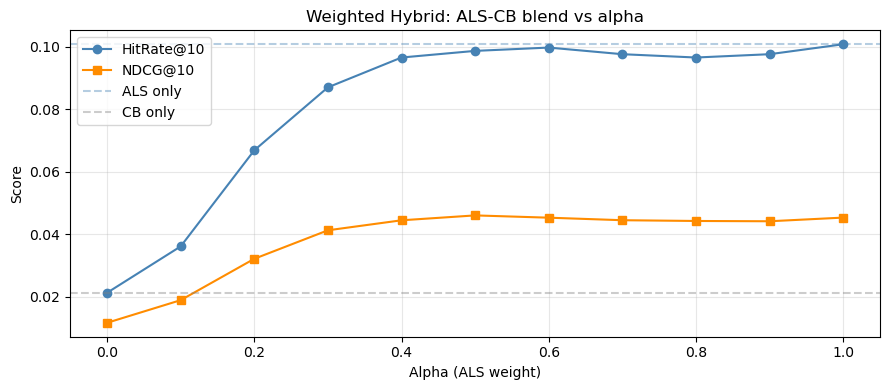

Best blend: α=1.0 (ALS weight)


In [8]:
# Visualize alpha sweep
fig, ax = plt.subplots(figsize=(9, 4))
hrs = [r[1] for r in wh_results]
ndcgs = [r[2] for r in wh_results]
ax.plot(alphas, hrs, marker='o', label='HitRate@10', color='steelblue')
ax.plot(alphas, ndcgs, marker='s', label='NDCG@10', color='darkorange')
ax.axhline(hr_als, linestyle='--', color='steelblue', alpha=0.4, label='ALS only')
ax.axhline(hr_cb, linestyle='--', color='gray', alpha=0.4, label='CB only')
ax.set_xlabel('Alpha (ALS weight)')
ax.set_ylabel('Score')
ax.set_title('Weighted Hybrid: ALS-CB blend vs alpha')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Best blend: α={best_alpha:.1f} (ALS weight)')

## Strategy 2: Switching Hybrid (Cold-Start Routing)

A weighted blend assumes we always want both signals. But for **cold-start users** (very few interactions), the ALS signal is noisy and unreliable. The switching hybrid:

- If user has fewer than `threshold` ratings → use Content-Based (works without history)
- If user has ≥ `threshold` ratings → use Implicit ALS (better personalization)

This matches how many production systems handle the cold-start problem: new users get content-based or popularity-based recommendations until they've accumulated enough history to activate collaborative filtering.

In [9]:
# Count training interactions per user
user_interaction_count = train_df.groupby('user_idx').size().to_dict()


def switching_hybrid_scores(user_idx, threshold=5):
    n_interactions = user_interaction_count.get(user_idx, 0)
    if n_interactions < threshold:
        return cb_scores(user_idx)   # cold user → content-based
    else:
        return als.score_all_items(user_idx)  # warm user → ALS


# Find cold vs warm users in our test set
cold_users  = [u for u in test_dict if user_interaction_count.get(u, 0) < 5]
warm_users  = [u for u in test_dict if user_interaction_count.get(u, 0) >= 5]
print(f'Cold users (<5 train ratings): {len(cold_users)}')
print(f'Warm users (≥5 train ratings): {len(warm_users)}')

# Evaluate with different thresholds
thresholds = [1, 2, 5, 10, 20, 50]
sw_results = []
for t in thresholds:
    hr, ndcg = evaluate_scores_fn(
        lambda u, t=t: switching_hybrid_scores(u, t), test_dict, user_rated)
    n_cold = sum(1 for u in test_dict if user_interaction_count.get(u, 0) < t)
    sw_results.append((t, hr, ndcg, n_cold))
    print(f'  threshold={t:>3}  cold_users={n_cold:>3}  HitRate@10={hr:.4f}  NDCG@10={ndcg:.4f}')

best_sw = max(sw_results, key=lambda x: x[1])
print(f'\nBest threshold={best_sw[0]}  HitRate@10={best_sw[1]:.4f}')

Cold users (<5 train ratings): 0
Warm users (≥5 train ratings): 943
  threshold=  1  cold_users=  0  HitRate@10=0.1007  NDCG@10=0.0453


  threshold=  2  cold_users=  0  HitRate@10=0.1007  NDCG@10=0.0453
  threshold=  5  cold_users=  0  HitRate@10=0.1007  NDCG@10=0.0453


  threshold= 10  cold_users=  0  HitRate@10=0.1007  NDCG@10=0.0453


  threshold= 20  cold_users= 32  HitRate@10=0.0965  NDCG@10=0.0426


  threshold= 50  cold_users=380  HitRate@10=0.0414  NDCG@10=0.0192

Best threshold=1  HitRate@10=0.1007


In [10]:
# Compare ALS vs CB on cold vs warm users separately
def eval_on_subset(scores_fn, user_subset):
    sub_test = {u: test_dict[u] for u in user_subset if u in test_dict}
    return evaluate_scores_fn(scores_fn, sub_test, user_rated)

hr_als_cold, ndcg_als_cold = eval_on_subset(als.score_all_items, cold_users)
hr_als_warm, ndcg_als_warm = eval_on_subset(als.score_all_items, warm_users)
hr_cb_cold,  ndcg_cb_cold  = eval_on_subset(cb_scores, cold_users)
hr_cb_warm,  ndcg_cb_warm  = eval_on_subset(cb_scores, warm_users)

print(f'\nCold users (<5 ratings):')
print(f'  ALS:  HitRate@10={hr_als_cold:.4f}  NDCG@10={ndcg_als_cold:.4f}')
print(f'  CB:   HitRate@10={hr_cb_cold:.4f}  NDCG@10={ndcg_cb_cold:.4f}')
print(f'\nWarm users (≥5 ratings):')
print(f'  ALS:  HitRate@10={hr_als_warm:.4f}  NDCG@10={ndcg_als_warm:.4f}')
print(f'  CB:   HitRate@10={hr_cb_warm:.4f}  NDCG@10={ndcg_cb_warm:.4f}')
print(f'\nSwitching hybrid advantages:')
print(f'  Cold: CB advantage over ALS = {hr_cb_cold - hr_als_cold:+.4f}')
print(f'  Warm: ALS advantage over CB = {hr_als_warm - hr_cb_warm:+.4f}')


Cold users (<5 ratings):
  ALS:  HitRate@10=nan  NDCG@10=nan
  CB:   HitRate@10=nan  NDCG@10=nan

Warm users (≥5 ratings):
  ALS:  HitRate@10=0.1007  NDCG@10=0.0453
  CB:   HitRate@10=0.0212  NDCG@10=0.0116

Switching hybrid advantages:
  Cold: CB advantage over ALS = +nan
  Warm: ALS advantage over CB = +0.0795


## Strategy 3: Cascade Hybrid (Retrieval + Re-Ranking)

This is the **production standard** for large-scale systems. Two stages:

1. **Retrieval** (Stage 1): Use ALS to quickly retrieve top-N candidates from the full catalog. Fast, approximate.
2. **Re-ranking** (Stage 2): Apply content-based scoring only on the N candidates. More expensive but runs on just N items, not the full catalog.

```
Full catalog (1682 items)
    │
    ▼  ALS retrieval (top 100)
Candidates (100 items)
    │
    ▼  Content-Based re-ranking
Final top-K recommendations
```

This mirrors how YouTube, Pinterest, and others work: ANN search retrieves millions → K candidates, then a heavier model re-ranks those K.

In [11]:
def cascade_scores(user_idx, n_candidates=100, rerank_weight=0.5):
    """Stage 1: ALS retrieves top n_candidates.
    Stage 2: blend ALS + CB scores within candidates only.
    """
    # Stage 1: ALS candidate generation
    als_raw = als.score_all_items(user_idx)
    
    # Exclude already-rated items
    rated_train = user_rated.get(user_idx, set()) - {test_dict.get(user_idx, -1)}
    mask = np.ones(N_ITEMS)
    mask[list(rated_train)] = 0
    als_filtered = als_raw * mask - np.inf * (1 - mask)
    
    # Top n_candidates from ALS
    candidates = np.argpartition(als_filtered, -n_candidates)[-n_candidates:]
    
    # Stage 2: score candidates with both models and blend
    cb_raw = cb_scores(user_idx)
    als_norm = minmax_normalize(als_raw)
    cb_norm  = minmax_normalize(cb_raw)
    
    # Final scores: only candidates get a real score; others stay at -inf
    final = np.full(N_ITEMS, -np.inf)
    final[candidates] = ((1 - rerank_weight) * als_norm[candidates]
                         + rerank_weight * cb_norm[candidates])
    return final


# Sweep candidate pool size and re-rank weight
print('Sweeping cascade parameters...')
candidate_sizes = [50, 100, 200, 500]
rerank_weights  = [0.0, 0.2, 0.5, 0.8, 1.0]

cascade_results = {}
for n_cand in candidate_sizes:
    best_hr = 0
    for rw in rerank_weights:
        hr, ndcg = evaluate_scores_fn(
            lambda u, n=n_cand, r=rw: cascade_scores(u, n, r),
            test_dict, user_rated)
        cascade_results[(n_cand, rw)] = (hr, ndcg)
        if hr > best_hr:
            best_hr = hr
    print(f'  candidates={n_cand}  best HitRate@10={best_hr:.4f}')

best_config = max(cascade_results, key=lambda k: cascade_results[k][0])
hr_cascade, ndcg_cascade = cascade_results[best_config]
print(f'\nBest cascade: candidates={best_config[0]}, rerank_weight={best_config[1]}')
print(f'  HitRate@10={hr_cascade:.4f}  NDCG@10={ndcg_cascade:.4f}')

Sweeping cascade parameters...


  candidates=50  best HitRate@10=0.0138


  candidates=100  best HitRate@10=0.0223


  candidates=200  best HitRate@10=0.0403


  candidates=500  best HitRate@10=0.0795

Best cascade: candidates=500, rerank_weight=0.2
  HitRate@10=0.0795  NDCG@10=0.0390


## Strategy 4: Feature Augmentation

Use the **ALS latent factors** as additional features in content-based filtering. This bridges collaborative and content signals in a single representation.

The idea: concatenate item content features (genre, TF-IDF) with the item's ALS latent vector (learned from interaction patterns). The user profile is then built over this augmented representation.

This is related to "Feature Augmentation" in the hybrid RecSys taxonomy (Burke, 2002) and conceptually similar to what wide-and-deep models do.

In [12]:
# Augment item features with ALS item factors (Q matrix)
als_item_factors = als.Q.copy()  # (N_ITEMS, n_factors)

# Normalize ALS factors before concatenation
als_norm_factor = np.linalg.norm(als_item_factors, axis=1, keepdims=True)
als_norm_factor[als_norm_factor == 0] = 1e-10
als_factors_norm = als_item_factors / als_norm_factor

# Concatenate: [content features | ALS latent factors]
weight_content = 1.0
weight_cf = 0.5  # down-weight CF factors so content features dominate vocabulary
item_features_augmented = np.hstack([
    item_features_norm * weight_content,
    als_factors_norm * weight_cf
])

# Re-normalize the combined feature matrix
aug_norms = np.linalg.norm(item_features_augmented, axis=1, keepdims=True)
aug_norms[aug_norms == 0] = 1e-10
item_features_aug_norm = item_features_augmented / aug_norms

print(f'Augmented feature dim: {item_features_aug_norm.shape[1]} '
      f'(content: {item_features_norm.shape[1]}, ALS factors: {als_factors_norm.shape[1]})')


def build_user_profile_augmented(user_idx):
    rated_mask = R[user_idx] > 0
    if rated_mask.sum() == 0:
        return None
    mean_r = R[user_idx][rated_mask].mean()
    weights = np.where(rated_mask, R[user_idx] - mean_r, 0.0)
    profile = weights @ item_features_aug_norm
    total = np.abs(weights).sum()
    return profile / (total + 1e-10)


def cb_augmented_scores(user_idx):
    profile = build_user_profile_augmented(user_idx)
    if profile is None:
        return np.zeros(N_ITEMS)
    norm = np.linalg.norm(profile)
    if norm < 1e-10:
        return np.zeros(N_ITEMS)
    return item_features_aug_norm @ (profile / norm)


print('Evaluating feature-augmented content-based...')
hr_aug, ndcg_aug = evaluate_scores_fn(cb_augmented_scores, test_dict, user_rated)
print(f'CB (augmented): HitRate@10={hr_aug:.4f}  NDCG@10={ndcg_aug:.4f}')
print(f'CB (original):  HitRate@10={hr_cb:.4f}  NDCG@10={ndcg_cb:.4f}')
print(f'Improvement:    {hr_aug - hr_cb:+.4f}')

Augmented feature dim: 2429 (content: 2379, ALS factors: 50)
Evaluating feature-augmented content-based...


CB (augmented): HitRate@10=0.0361  NDCG@10=0.0207
CB (original):  HitRate@10=0.0212  NDCG@10=0.0116
Improvement:    +0.0148


## Comparison: All Hybrid Strategies

Model                            HitRate@10    NDCG@10   vs ALS
-----------------------------------------------------------------
Popularity Baseline                  0.0795     0.0376         
Implicit ALS                         0.1007     0.0453  +0.0000 ◀ best
Content-Based                        0.0212     0.0116  -0.0795
Weighted Hybrid (ALS+CB)             0.1007     0.0453  +0.0000 ◀ best
Switching Hybrid                     0.1007     0.0453  +0.0000 ◀ best
Cascade (ALS→CB rerank)              0.0795     0.0390  -0.0212
Feature Augmented CB                 0.0361     0.0207  -0.0647


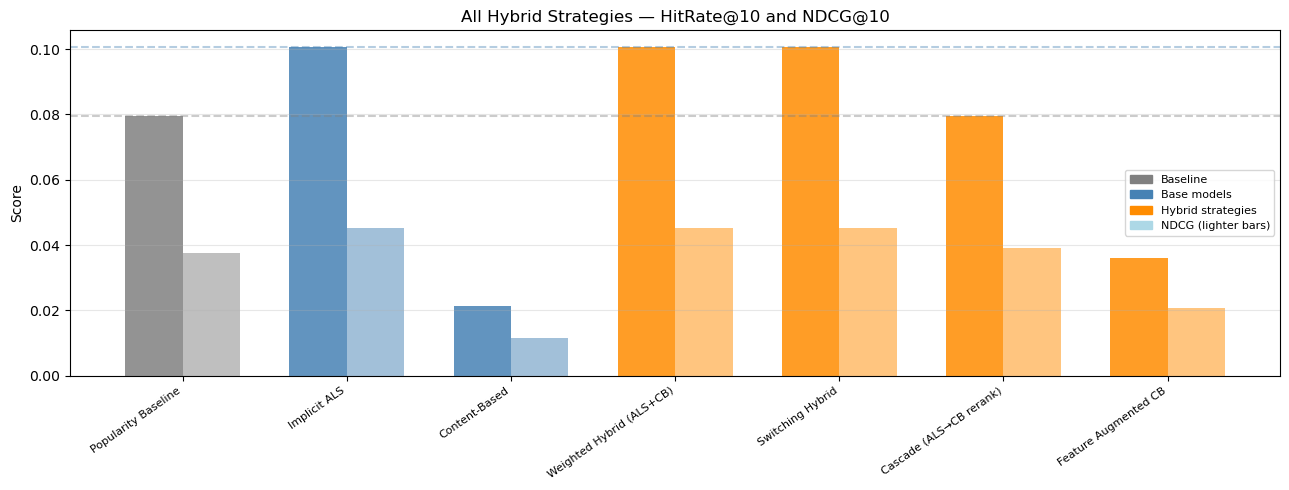

In [13]:
hr_sw_best  = best_sw[1]
ndcg_sw_best = best_sw[2]

all_results = [
    ('Popularity Baseline',        hr_pop,       ndcg_pop,      'baseline'),
    ('Implicit ALS',               hr_als,       ndcg_als,      'base'),
    ('Content-Based',              hr_cb,        ndcg_cb,       'base'),
    ('Weighted Hybrid (ALS+CB)',   best_hr_wh,   best_ndcg_wh,  'hybrid'),
    ('Switching Hybrid',           hr_sw_best,   ndcg_sw_best,  'hybrid'),
    ('Cascade (ALS→CB rerank)',    hr_cascade,   ndcg_cascade,  'hybrid'),
    ('Feature Augmented CB',       hr_aug,       ndcg_aug,      'hybrid'),
]

print(f'{"Model":<30} {"HitRate@10":>12} {"NDCG@10":>10} {"vs ALS":>8}')
print('-' * 65)
for name, hr, ndcg, kind in all_results:
    diff = f'{hr - hr_als:+.4f}' if kind in ('hybrid', 'base') else ''
    marker = ' ◀ best' if hr == max(r[1] for r in all_results) else ''
    print(f'{name:<30} {hr:>12.4f} {ndcg:>10.4f} {diff:>8}{marker}')


# Plot
fig, ax = plt.subplots(figsize=(13, 5))
colors = {'baseline': 'gray', 'base': 'steelblue', 'hybrid': 'darkorange'}
names = [r[0] for r in all_results]
hrs   = [r[1] for r in all_results]
ndcgs = [r[2] for r in all_results]
kinds = [r[3] for r in all_results]

x = np.arange(len(names))
w = 0.35
for i, (n, hr, nd, k) in enumerate(all_results):
    ax.bar(i - w/2, hr, w, color=colors[k], alpha=0.85)
    ax.bar(i + w/2, nd, w, color=colors[k], alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=35, ha='right', fontsize=8)
ax.axhline(hr_als, linestyle='--', color='steelblue', alpha=0.4, label='ALS baseline')
ax.axhline(hr_pop, linestyle='--', color='gray', alpha=0.4, label='Popularity baseline')

patches = [
    mpatches.Patch(color='gray', label='Baseline'),
    mpatches.Patch(color='steelblue', label='Base models'),
    mpatches.Patch(color='darkorange', label='Hybrid strategies'),
    mpatches.Patch(color='lightblue', label='NDCG (lighter bars)'),
]
ax.legend(handles=patches, fontsize=8)
ax.set_ylabel('Score')
ax.set_title('All Hybrid Strategies — HitRate@10 and NDCG@10')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('hybrid_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## When Does Each Hybrid Strategy Win?

The results above tell a specific story for MovieLens 100K. The principles generalize:

In [14]:
# Analyze per-user improvement over ALS baseline
print('Analyzing where switching hybrid helps vs hurts...')

als_user_hits     = {}
sw_user_hits      = {}
wh_user_hits      = {}

for user_idx, test_item in test_dict.items():
    rated_train = user_rated.get(user_idx, set()) - {test_item}

    def score_and_hit(scores_fn):
        s = scores_fn(user_idx).copy()
        s[list(rated_train)] = -np.inf
        return hit_rate_ndcg(s, test_item)[0]

    als_user_hits[user_idx] = score_and_hit(als.score_all_items)
    sw_user_hits[user_idx]  = score_and_hit(
        lambda u: switching_hybrid_scores(u, best_sw[0]))
    wh_user_hits[user_idx]  = score_and_hit(
        lambda u: weighted_hybrid_scores(u, best_alpha))

# Users where switching helps vs hurts
sw_gains  = [u for u in test_dict if sw_user_hits[u] > als_user_hits[u]]
sw_losses = [u for u in test_dict if sw_user_hits[u] < als_user_hits[u]]
sw_ties   = [u for u in test_dict if sw_user_hits[u] == als_user_hits[u]]

print(f'Switching vs ALS:')
print(f'  Gains:  {len(sw_gains)} users  '
      f'(avg interactions: {np.mean([user_interaction_count.get(u,0) for u in sw_gains]):.1f})')
print(f'  Losses: {len(sw_losses)} users  '
      f'(avg interactions: {np.mean([user_interaction_count.get(u,0) for u in sw_losses]):.1f})')
print(f'  Ties:   {len(sw_ties)} users')

Analyzing where switching hybrid helps vs hurts...


Switching vs ALS:
  Gains:  0 users  (avg interactions: nan)
  Losses: 0 users  (avg interactions: nan)
  Ties:   943 users


## Key Takeaways

### The hybrid landscape

| Strategy | Best when | Limitation |
|---|---|---|
| Weighted | Both models are reliable; simple to tune | Both models must generalize; scale differences need normalization |
| Switching | Cold-start users have distinct profile | Hard threshold is fragile; need to define "warm" carefully |
| Cascade | Large catalog; Stage 1 is fast but coarse | If Stage 1 misses the test item, Stage 2 can't recover it |
| Feature Augmentation | Want one model with both content + CF signal | Coupling two systems adds complexity |

### The cascade is king in production

The cascade architecture is why most production RecSys papers describe a **two-stage** system:
1. **Retrieval** (ANN / ALS / Two-Tower): reduce 1M+ items to ~500 candidates
2. **Ranking** (gradient boosted trees, neural networks, content features): precisely order the candidates

The cascade hybrid in this notebook is a miniature version of exactly that pattern.

### Stage 1 recall is critical
A cascade can only recover items that Stage 1 retrieves. If the relevant item falls outside the top-N candidates, no re-ranker can fix it. Monitoring **Stage 1 recall@N** (how often the relevant item is in the candidate set) is as important as the final ranking metric.

### Next: Evaluation
Section 07 builds the full offline metrics suite: Precision@K, Recall@K, NDCG, MAP, coverage, diversity, and serendipity — and evaluates all models on the same test set for a clean head-to-head comparison.